# Ejercicio 8

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform

/tmp/ipykernel_33555/3178576440.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posterior_uniforme /= np.trapz(posterior_uniforme, p)
/tmp/ipykernel_33555/3178576440.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posterior_gaussiano /= np.trapz(posterior_gaussiano, p)


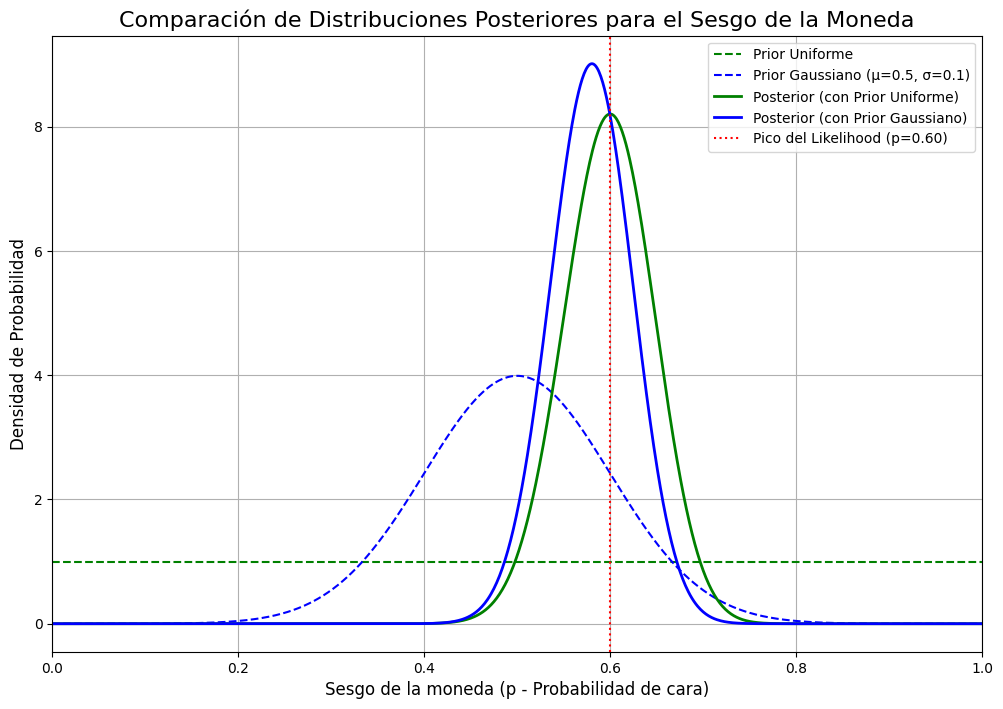

In [3]:
def calcular_posterior_moneda(n_lanzamientos, n_caras):
    """
    Calcula y grafica la probabilidad posterior del sesgo de una moneda (p)
    utilizando un prior uniforme y uno gaussiano.
    """
    # 1. Definir el espacio de parámetros para 'p' (el sesgo de la moneda)
    # Creamos 1001 puntos entre 0 y 1 para representar todos los posibles valores de p.
    p = np.linspace(0, 1, 1001)

    # 2. Calcular el Likelihood
    # La probabilidad de obtener 'n_caras' en 'n_lanzamientos' para cada valor de p
    # se rige por la distribución Binomial.
    # P(datos|p) ∝ p^k * (1-p)^(n-k)
    n_secas = n_lanzamientos - n_caras
    likelihood = p**n_caras * (1 - p)**n_secas

    # 3. Definir los Priors
    # Prior Uniforme: Todos los valores de p son igualmente probables.
    prior_uniforme = uniform.pdf(p, loc=0, scale=1)
    
    # Prior Gaussiano: Creemos que p está cerca de 0.5.
    prior_gaussiano = norm.pdf(p, loc=0.5, scale=0.1)

    # 4. Calcular la Probabilidad Posterior (sin normalizar)
    # Posterior ∝ Likelihood × Prior
    posterior_uniforme = likelihood * prior_uniforme
    posterior_gaussiano = likelihood * prior_gaussiano

    # 5. Normalizar las distribuciones posteriores para que su área sea 1
    # Esto las convierte en distribuciones de probabilidad válidas.
    posterior_uniforme /= np.trapz(posterior_uniforme, p)
    posterior_gaussiano /= np.trapz(posterior_gaussiano, p)

    # 6. Realizar el gráfico de comparación
    plt.figure(figsize=(12, 8))
    
    # Graficar Priors
    plt.plot(p, prior_uniforme, 'g--', label='Prior Uniforme')
    plt.plot(p, prior_gaussiano, 'b--', label='Prior Gaussiano (μ=0.5, σ=0.1)')

    # Graficar Posteriors
    plt.plot(p, posterior_uniforme, 'g-', label='Posterior (con Prior Uniforme)', lw=2)
    plt.plot(p, posterior_gaussiano, 'b-', label='Posterior (con Prior Gaussiano)', lw=2)
    
    # Encontrar y marcar el pico del likelihood (Estimación de Máxima Verosimilitud)
    max_likelihood_p = p[np.argmax(likelihood)]
    plt.axvline(max_likelihood_p, color='r', linestyle=':', 
                label=f'Pico del Likelihood (p={max_likelihood_p:.2f})')

    plt.title('Comparación de Distribuciones Posteriores para el Sesgo de la Moneda', fontsize=16)
    plt.xlabel('Sesgo de la moneda (p - Probabilidad de cara)', fontsize=12)
    plt.ylabel('Densidad de Probabilidad', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 1)
    plt.show()

# --- Ejecutar la función con los datos del ejercicio ---
# 100 lanzamientos, 60 caras
calcular_posterior_moneda(n_lanzamientos=100, n_caras=60)